# Imports 

In [40]:
import pandas as pd

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Bank Transaction Fraud Detection

## Dataset Description
This dataset contains 200,000 bank transaction records from Indian banks with features including customer demographics, transaction details, and fraud labels. The goal is to build machine learning models to detect fraudulent transactions.

In [42]:
df = pd.read_csv('other_data/Bank_Transaction_Fraud_Detection.csv')

## Data Extraction

In [43]:
df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [44]:
df.shape

(200000, 24)

In [45]:
df.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Amount', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Customer_Contact', 'Transaction_Description',
       'Customer_Email'],
      dtype='object')

In [46]:
columns_to_drop = ["Customer_ID","Customer_Name", "Transaction_ID", "Merchant_ID","Customer_Contact","Transaction_Description", "Customer_Email", "Transaction_Currency"]
df.drop(columns=columns_to_drop, axis=1, inplace=True)

## Exploratory Data Analysis

In [47]:
df.head()

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Date,Transaction_Time,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud
0,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,23-01-2025,16:04:07,32415.45,Transfer,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0
1,Female,51,Maharashtra,Nashik,Nashik Branch,Business,11-01-2025,17:14:53,43622.60,Bill Payment,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0
2,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,25-01-2025,03:09:52,63062.56,Bill Payment,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0
3,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,19-01-2025,12:27:02,14000.72,Debit,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0
4,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,30-01-2025,18:30:46,18335.16,Transfer,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0


In [75]:
df["Is_Fraud"].unique()

array([0, 1])

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                200000 non-null  object 
 1   Age                   200000 non-null  int64  
 2   State                 200000 non-null  object 
 3   City                  200000 non-null  object 
 4   Bank_Branch           200000 non-null  object 
 5   Account_Type          200000 non-null  object 
 6   Transaction_Date      200000 non-null  object 
 7   Transaction_Time      200000 non-null  object 
 8   Transaction_Amount    200000 non-null  float64
 9   Transaction_Type      200000 non-null  object 
 10  Merchant_Category     200000 non-null  object 
 11  Account_Balance       200000 non-null  float64
 12  Transaction_Device    200000 non-null  object 
 13  Transaction_Location  200000 non-null  object 
 14  Device_Type           200000 non-null  object 
 15  

In [49]:
df["year"] = pd.to_datetime(df["Transaction_Date"]).dt.year
df["month"] = pd.to_datetime(df["Transaction_Date"]).dt.month
df["day"] = pd.to_datetime(df["Transaction_Date"]).dt.day

df["hour"] = pd.to_datetime(df["Transaction_Time"], format="%H:%M:%S").dt.hour
df["minute"] = pd.to_datetime(df["Transaction_Time"], format="%H:%M:%S").dt.minute
df["second"] = pd.to_datetime(df["Transaction_Time"], format="%H:%M:%S").dt.second

df.drop(["Transaction_Time", "Transaction_Date"], axis=1, inplace=True)

/tmp/ipykernel_7513/489643442.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["year"] = pd.to_datetime(df["Transaction_Date"]).dt.year
/tmp/ipykernel_7513/489643442.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["month"] = pd.to_datetime(df["Transaction_Date"]).dt.month
/tmp/ipykernel_7513/489643442.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["day"] = pd.to_datetime(df["Transaction_Date"]).dt.day


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                200000 non-null  object 
 1   Age                   200000 non-null  int64  
 2   State                 200000 non-null  object 
 3   City                  200000 non-null  object 
 4   Bank_Branch           200000 non-null  object 
 5   Account_Type          200000 non-null  object 
 6   Transaction_Amount    200000 non-null  float64
 7   Transaction_Type      200000 non-null  object 
 8   Merchant_Category     200000 non-null  object 
 9   Account_Balance       200000 non-null  float64
 10  Transaction_Device    200000 non-null  object 
 11  Transaction_Location  200000 non-null  object 
 12  Device_Type           200000 non-null  object 
 13  Is_Fraud              200000 non-null  int64  
 14  year                  200000 non-null  int32  
 15  

In [51]:
df.duplicated().sum()

np.int64(0)

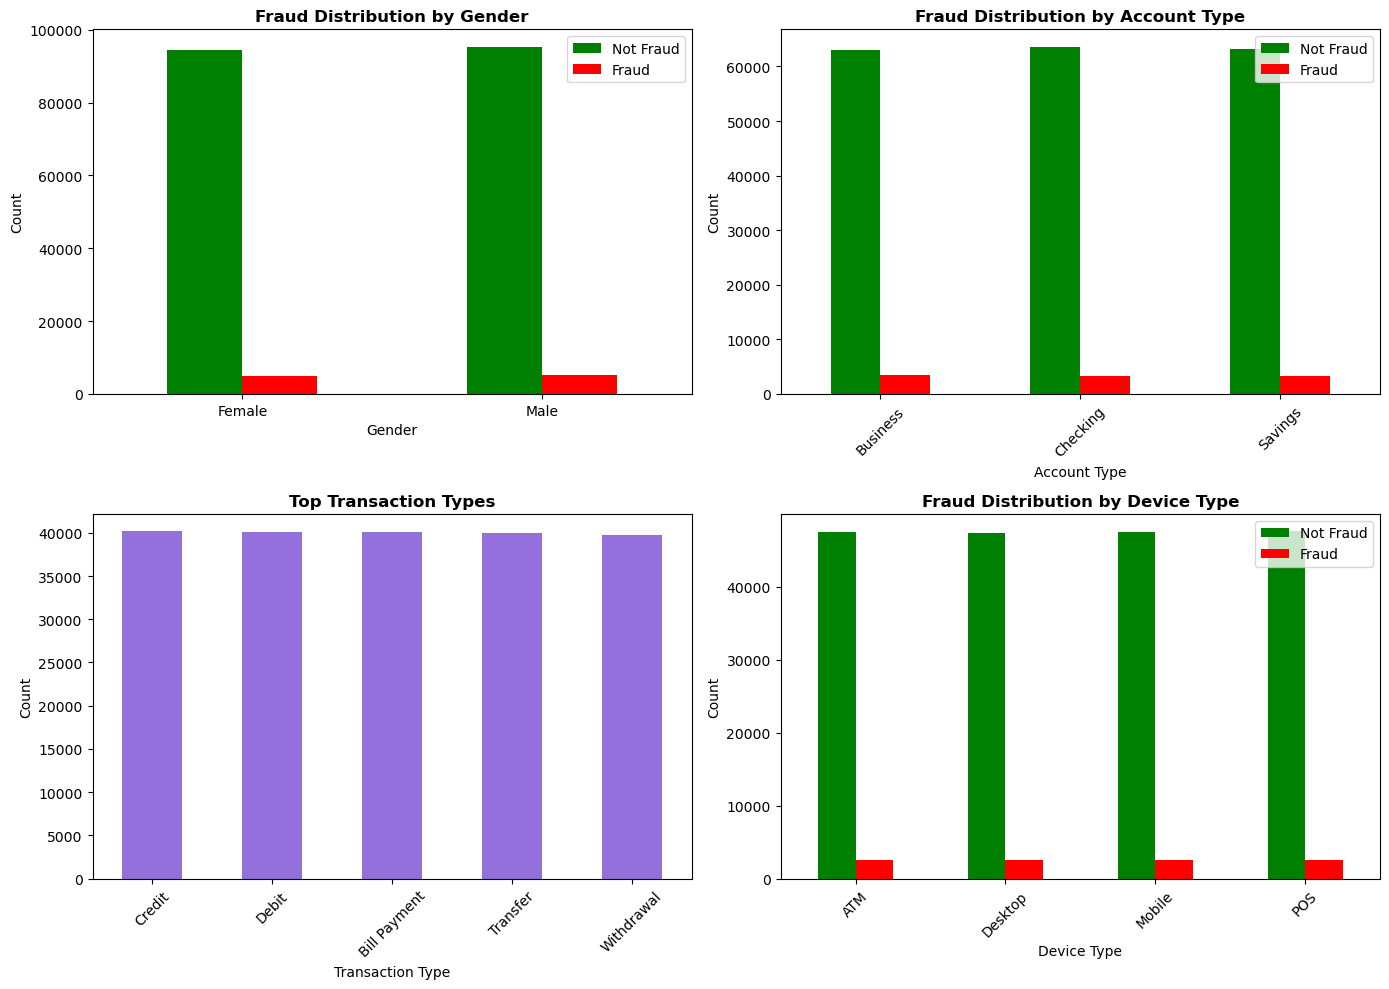

In [52]:
# Categorical features distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
gender_fraud = df.groupby(['Gender', 'Is_Fraud']).size().unstack(fill_value=0)
gender_fraud.plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Fraud Distribution by Gender', fontweight='bold')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(['Not Fraud', 'Fraud'])
axes[0, 0].tick_params(axis='x', rotation=0)

# Account Type
account_fraud = df.groupby(['Account_Type', 'Is_Fraud']).size().unstack(fill_value=0)
account_fraud.plot(kind='bar', ax=axes[0, 1], color=['green', 'red'])
axes[0, 1].set_title('Fraud Distribution by Account Type', fontweight='bold')
axes[0, 1].set_xlabel('Account Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(['Not Fraud', 'Fraud'])
axes[0, 1].tick_params(axis='x', rotation=45)

# Transaction Type
trans_type = df['Transaction_Type'].value_counts().head(10)
trans_type.plot(kind='bar', ax=axes[1, 0], color='mediumpurple')
axes[1, 0].set_title('Top Transaction Types', fontweight='bold')
axes[1, 0].set_xlabel('Transaction Type')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Device Type
device_fraud = df.groupby(['Device_Type', 'Is_Fraud']).size().unstack(fill_value=0)
device_fraud.plot(kind='bar', ax=axes[1, 1], color=['green', 'red'])
axes[1, 1].set_title('Fraud Distribution by Device Type', fontweight='bold')
axes[1, 1].set_xlabel('Device Type')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(['Not Fraud', 'Fraud'])
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

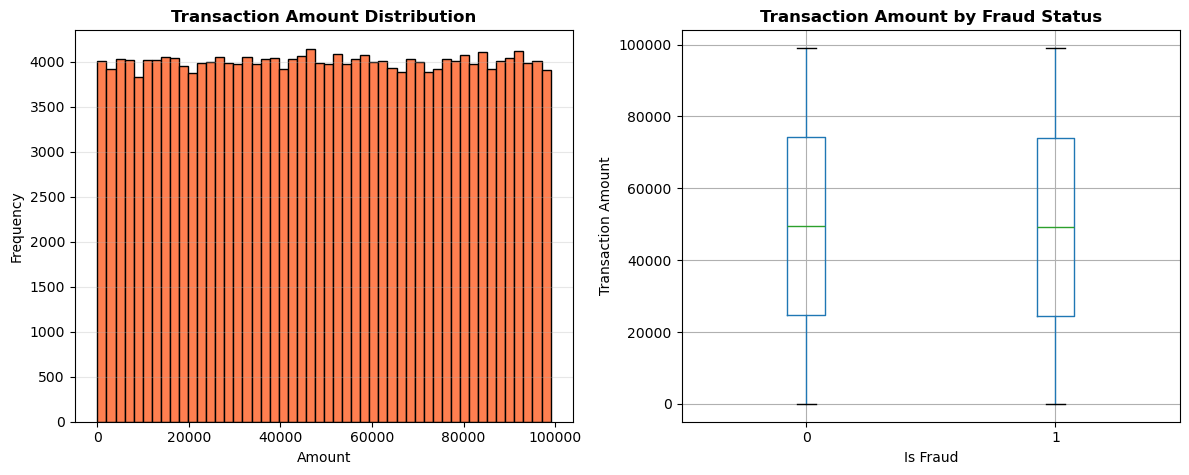

In [53]:
# Transaction amount distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Transaction_Amount'], bins=50, color='coral', edgecolor='black')
plt.title('Transaction Amount Distribution', fontweight='bold')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
df.boxplot(column='Transaction_Amount', by='Is_Fraud', ax=plt.gca())
plt.title('Transaction Amount by Fraud Status', fontweight='bold')
plt.suptitle('')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')

plt.tight_layout()
plt.show()

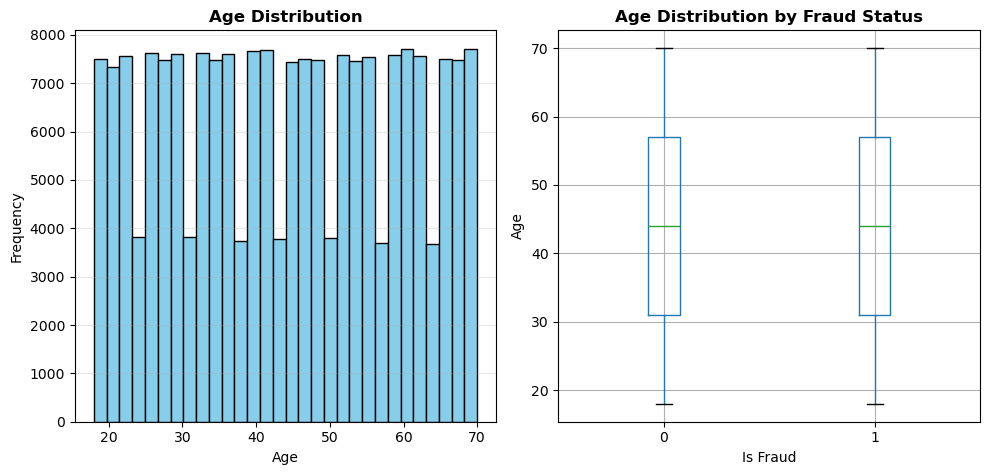

In [54]:
# Age distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
df.boxplot(column='Age', by='Is_Fraud', figsize=(5, 5), ax=plt.gca())
plt.title('Age Distribution by Fraud Status', fontweight='bold')
plt.suptitle('')
plt.xlabel('Is Fraud')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

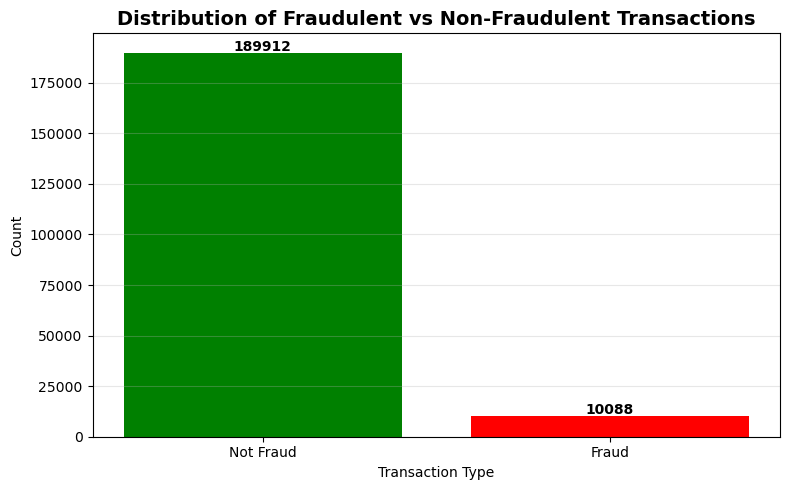

In [55]:
# Fraud distribution
plt.figure(figsize=(8, 5))
fraud_counts = df['Is_Fraud'].value_counts()
plt.bar(['Not Fraud', 'Fraud'], fraud_counts.values, color=['green', 'red'])
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(fraud_counts.values):
    plt.text(i, v + 1000, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [56]:
df.isnull().sum()

Gender                  0
Age                     0
State                   0
City                    0
Bank_Branch             0
Account_Type            0
Transaction_Amount      0
Transaction_Type        0
Merchant_Category       0
Account_Balance         0
Transaction_Device      0
Transaction_Location    0
Device_Type             0
Is_Fraud                0
year                    0
month                   0
day                     0
hour                    0
minute                  0
second                  0
dtype: int64

In [57]:
Categorical = [i for i in df.columns if df[i].dtype == 'O']
Numerical = [i for i in df.columns if df[i].dtype != 'O']

In [58]:
print(f"Categorical: \n{Categorical}\n\nNumerical: \n{Numerical}")

Categorical: 
['Gender', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 'Transaction_Device', 'Transaction_Location', 'Device_Type']

Numerical: 
['Age', 'Transaction_Amount', 'Account_Balance', 'Is_Fraud', 'year', 'month', 'day', 'hour', 'minute', 'second']


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold 
from imblearn.over_sampling import SMOTE

## Data Transformation

In [60]:
label_encoder = LabelEncoder()
for i in Categorical:
    df[i] = label_encoder.fit_transform(df[i])

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                200000 non-null  int64  
 1   Age                   200000 non-null  int64  
 2   State                 200000 non-null  int64  
 3   City                  200000 non-null  int64  
 4   Bank_Branch           200000 non-null  int64  
 5   Account_Type          200000 non-null  int64  
 6   Transaction_Amount    200000 non-null  float64
 7   Transaction_Type      200000 non-null  int64  
 8   Merchant_Category     200000 non-null  int64  
 9   Account_Balance       200000 non-null  float64
 10  Transaction_Device    200000 non-null  int64  
 11  Transaction_Location  200000 non-null  int64  
 12  Device_Type           200000 non-null  int64  
 13  Is_Fraud              200000 non-null  int64  
 14  year                  200000 non-null  int32  
 15  

In [ ]:
X = df.drop(columns=['Is_Fraud'])
Y = df["Is_Fraud"]

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.1, stratify=Y)

In [63]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(x_train)
x_train_scaled = pd.DataFrame(scaled_data, columns=x_train.columns)

x_train_scaled

,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,year,month,day,hour,minute,second
0,-1.004789,1.699693,-0.870409,0.818879,0.818879,-1.226281,0.521015,1.418576,-0.877912,-1.352939,0.725504,0.813379,-1.341241,0.0,0.0,-0.173705,-0.069890,0.145966,1.240542
1,-1.004789,0.261309,0.558049,-0.924634,-0.924634,1.225191,0.031147,0.710910,1.462363,-1.134834,0.234631,-0.905872,-1.341241,0.0,0.0,-0.058411,-1.516036,-1.531920,-0.547275
2,0.995234,-0.654026,1.476343,-0.136471,-0.136471,1.225191,-1.427748,0.710910,-1.462981,1.219607,-0.747113,-0.128676,-1.341241,0.0,0.0,-0.980761,1.376257,0.435256,0.144783
3,0.995234,0.130547,1.272277,-0.040936,-0.040936,1.225191,0.376473,-1.412089,0.292226,0.705169,0.725504,-0.034471,-0.447603,0.0,0.0,1.325114,0.363954,0.955980,1.355885
4,0.995234,1.242025,1.272277,-0.494727,-0.494727,-1.226281,-1.288848,-0.704423,1.462363,0.059001,1.216376,-0.481947,-1.341241,0.0,0.0,-1.557229,1.665486,0.724547,1.701915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179995,0.995234,1.634312,0.762114,0.293437,0.293437,-1.226281,-1.323735,0.710910,-1.462981,0.780143,0.234631,0.295248,1.339672,0.0,0.0,-1.326642,0.653183,-1.531920,0.548484
179996,-1.004789,-0.130978,-0.870409,-0.829099,-0.829099,-0.000545,0.876530,-0.704423,0.877295,0.971582,1.052752,-0.811667,-0.447603,0.0,0.0,1.555701,-1.082192,1.708135,1.355885
179997,0.995234,-1.373218,-0.156180,1.415973,1.415973,-1.226281,-1.181395,-1.412089,-1.462981,1.635512,-0.583489,1.402163,0.446034,0.0,0.0,0.748645,-1.226807,0.203824,-0.258918
179998,-1.004789,1.503550,0.762114,0.293437,0.293437,-1.226281,1.558467,-0.704423,0.292226,1.018872,-0.910737,0.295248,0.446034,0.0,0.0,0.518058,0.653183,1.303128,0.490812


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

## Model Loading

In [65]:
log_model = LogisticRegression(class_weight='balanced')
log_model.fit(x_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

## Model Training and Testing

### Logistic Regression

In [66]:
y_pred = log_model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     19043
           1       0.00      0.00      0.00       957

    accuracy                           0.95     20000
   macro avg       0.48      0.50      0.49     20000
weighted avg       0.91      0.95      0.93     20000



/home/theslender/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/theslender/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/theslender/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [67]:
rf_model = RandomForestClassifier(n_estimators=50)

rf_model.fit(x_train_scaled, y_train)

RandomForestClassifier(n_estimators=50)

### Random Forest Classifier

In [68]:
rf_y_pred = rf_model.predict(x_test)
print(classification_report(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     19043
           1       0.00      0.00      0.00       957

    accuracy                           0.95     20000
   macro avg       0.48      0.50      0.49     20000
weighted avg       0.91      0.95      0.93     20000



In [69]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight)
xgb_model.fit(x_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

### XGBoost Classifier

In [70]:
xgb_y_pred = xgb_model.predict(x_test)
print(classification_report(xgb_y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     19985
           1       0.00      0.07      0.00        15

    accuracy                           0.95     20000
   macro avg       0.50      0.51      0.49     20000
weighted avg       1.00      0.95      0.97     20000

